In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn.utils.rnn import pad_sequence
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

os.makedirs('../data/images/bert_bertweet_large', exist_ok=True)
os.makedirs('../models/bert_bertweet_large', exist_ok=True)

In [10]:
# =============================================================================
# CONFIGURATION
# =============================================================================
#
# vinai/bertweet-large: the large variant of BERTweet.
# Same domain-specific pre-training on Twitter data as bertweet-base,
# but with a larger architecture (24 layers vs 12, hidden size 1024 vs 768).
#
# Comparison:
#   bertweet-base  : 135M params, 12 layers, hidden 768,  max_length 128
#   bertweet-large : 355M params, 24 layers, hidden 1024, max_length 512
#
# Both are pre-trained on English tweets — same domain as this task.
# The large variant has more capacity to capture nuanced semantics.
# Model: https://huggingface.co/vinai/bertweet-large
#
# Label Smoothing (Szegedy et al. 2016):
# Instead of training with hard targets {0, 1}, label smoothing uses
# soft targets {ε/2, 1-ε/2} — e.g. {0.05, 0.95} with ε=0.1.
# This prevents the model from becoming overconfident on ambiguous samples,
# which is especially relevant here given the 18 mislabeled samples we
# corrected manually. Even after correction, some tweets remain genuinely
# ambiguous (e.g. metaphorical use of disaster keywords).
# Source: inspired by the multi-sample dropout notebook analysis.

MODEL_CHECKPOINT      = 'vinai/bertweet-large'
MAX_LENGTH            = 128   # tweets are short — 128 is sufficient even for large
BATCH_SIZE            = 8     # reduced from 16 due to larger model memory footprint
LEARNING_RATE         = 1e-5  # lower lr for large models — more stable convergence
NUM_EPOCHS            = 3
VAL_SIZE              = 0.1
SEED                  = 42
WARMUP_RATIO          = 0.1   # warm up for first 10% of steps

In [11]:
# =============================================================================
# LOAD DATA
# =============================================================================

df_full = pd.read_csv('../data/augmented_train.csv')
df_test = pd.read_csv('../data/test_cleaned.csv')

# Keep only original rows — augmented rows (back-translations) are excluded
# from validation to avoid inflated scores
original_max_id = df_full['id'].max() // 2
df_orig = df_full[df_full['id'] <= original_max_id].copy()

print(f"Original training rows : {len(df_orig)}")
print(f"Test rows              : {len(df_test)}")
print(f"\nLabel distribution (original):")
print(df_orig['target_relabeled'].value_counts(normalize=True).round(3))

Original training rows : 7613
Test rows              : 3263

Label distribution (original):
target_relabeled
0    0.572
1    0.428
Name: proportion, dtype: float64


In [12]:
# =============================================================================
# TRAIN / VALIDATION SPLIT
# =============================================================================

df_work = df_orig[['text_cleaned', 'target_relabeled']].dropna()
df_work = df_work.rename(columns={'target_relabeled': 'label'})
df_work = df_work.drop_duplicates(subset='text_cleaned')

train_df, val_df = train_test_split(
    df_work,
    test_size=VAL_SIZE,
    stratify=df_work['label'],
    random_state=SEED
)

overlap = len(set(train_df['text_cleaned']) & set(val_df['text_cleaned']))
print(f"\nTrain size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print(f"Overlap    : {overlap}  ← must be 0")


Train size : 6286
Val size   : 699
Overlap    : 0  ← must be 0


In [13]:
# =============================================================================
# TOKENIZATION
# =============================================================================
# BERTweet-large uses BPE tokenization (same as RoBERTa) with a Twitter-
# specific vocabulary. normalization=True activates BERTweet's built-in
# tweet normalization: URLs → HTTPURL, mentions → @USER.
# use_fast=False is required for BERTweet tokenizer compatibility.

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_CHECKPOINT,
    use_fast=False,
    normalization=True
)

def tokenize(example):
    return tokenizer(
        example['text_cleaned'],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)

print(f"\nTokenization complete.")
print(f"Train dataset features: {train_dataset.features}")

Map:   0%|          | 0/6286 [00:00<?, ? examples/s]

Map:   0%|          | 0/699 [00:00<?, ? examples/s]


Tokenization complete.
Train dataset features: {'text_cleaned': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [14]:
# =============================================================================
# MODEL
# =============================================================================
# vinai/bertweet-large: RoBERTa-large architecture, 24 Transformer layers,
# hidden size 1024, 16 attention heads, ~355M parameters.
# Pre-trained on 873M English tweets (Nguyen et al. 2020).
#
# ignore_mismatched_sizes=True is required because the pre-training checkpoint
# has a language model head with different output dimensions than the
# classification head we add here.
#
# UNEXPECTED keys = pre-training heads (not needed for classification)
# MISSING keys    = new classification head (randomly initialized, will be trained)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    ignore_mismatched_sizes=True
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*50}")
print(f"  PARAMETER COUNT")
print(f"{'='*50}")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Trainable %          : {100 * trainable_params / total_params:.2f}%")
print(f"{'='*50}")
print(f"\n  bertweet-base  : ~135M parameters")
print(f"  bertweet-large : ~355M parameters  ← this model")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  PARAMETER COUNT
  Total parameters     : 355,361,794
  Trainable parameters : 355,361,794
  Trainable %          : 100.00%

  bertweet-base  : ~135M parameters
  bertweet-large : ~355M parameters  ← this model


In [15]:
# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'f1': f1_score(labels, preds)}

In [16]:
# =============================================================================
# TRAINING
# =============================================================================
# Key differences vs bert_bertweet.ipynb:
#   - label_smoothing_factor=0.1: soft targets prevent overconfidence on
#     ambiguous tweets (metaphorical disaster language, mislabeled samples)
#   - learning_rate=1e-5: lower than bertweet-base (2e-5) — large models
#     need more conservative updates to avoid catastrophic forgetting
#   - per_device_train_batch_size=8: reduced from 16 to fit GPU memory
#   - warmup_ratio=0.1: warm up LR for first 10% of steps (same as base)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir                  = '../models/bert_bertweet_large',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    num_train_epochs            = NUM_EPOCHS,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    seed                        = SEED,
    warmup_ratio                = WARMUP_RATIO,
    report_to                   = 'none'
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = data_collator,
    compute_metrics = compute_metrics
)

print("\nStarting BERTweet-large fine-tuning...")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Warmup ratio    : {WARMUP_RATIO}")
train_result = trainer.train()
print("\nTraining complete.")
print(train_result)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Starting BERTweet-large fine-tuning...
  Learning rate   : 1e-05
  Batch size      : 8
  Warmup ratio    : 0.1


Epoch,Training Loss,Validation Loss,F1
1,0.596426,0.376581,0.807143
2,0.417592,0.419290,0.798493
3,0.355219,0.562943,0.812165


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete.
TrainOutput(global_step=2358, training_loss=0.44473023289234787, metrics={'train_runtime': 877.2321, 'train_samples_per_second': 21.497, 'train_steps_per_second': 2.688, 'total_flos': 1522237074858528.0, 'train_loss': 0.44473023289234787, 'epoch': 3.0})


In [17]:
# =============================================================================
# EVALUATION — manual loop
# Works on both CPU (Windows deadlock workaround) and GPU (Lightning/Kaggle)
# =============================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
model.eval()
all_preds = []

for i in range(0, len(val_dataset), BATCH_SIZE):
    batch          = val_dataset[i:i+BATCH_SIZE]
    input_ids      = [torch.tensor(x) for x in batch['input_ids']]
    attention_mask = [torch.tensor(x) for x in batch['attention_mask']]
    input_ids      = pad_sequence(input_ids, batch_first=True, padding_value=0).to(device)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_preds.extend(preds)
    print(f"  {min(i+BATCH_SIZE, len(val_dataset))}/{len(val_dataset)}")

val_preds  = np.array(all_preds)
val_labels = val_df['label'].values
val_f1     = f1_score(val_labels, val_preds)

print(f"\nValidation F1 : {val_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(val_labels, val_preds,
      target_names=['Not Disaster', 'Disaster']))

eval_result = {'eval_f1': val_f1}

  8/699
  16/699
  24/699
  32/699
  40/699
  48/699
  56/699
  64/699
  72/699
  80/699
  88/699
  96/699
  104/699
  112/699
  120/699
  128/699
  136/699
  144/699
  152/699
  160/699
  168/699
  176/699
  184/699
  192/699
  200/699
  208/699
  216/699
  224/699
  232/699
  240/699
  248/699
  256/699
  264/699
  272/699
  280/699
  288/699
  296/699
  304/699
  312/699
  320/699
  328/699
  336/699
  344/699
  352/699
  360/699
  368/699
  376/699
  384/699
  392/699
  400/699
  408/699
  416/699
  424/699
  432/699
  440/699
  448/699
  456/699
  464/699
  472/699
  480/699
  488/699
  496/699
  504/699
  512/699
  520/699
  528/699
  536/699
  544/699
  552/699
  560/699
  568/699
  576/699
  584/699
  592/699
  600/699
  608/699
  616/699
  624/699
  632/699
  640/699
  648/699
  656/699
  664/699
  672/699
  680/699
  688/699
  696/699
  699/699

Validation F1 : 0.8122

Detailed Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.

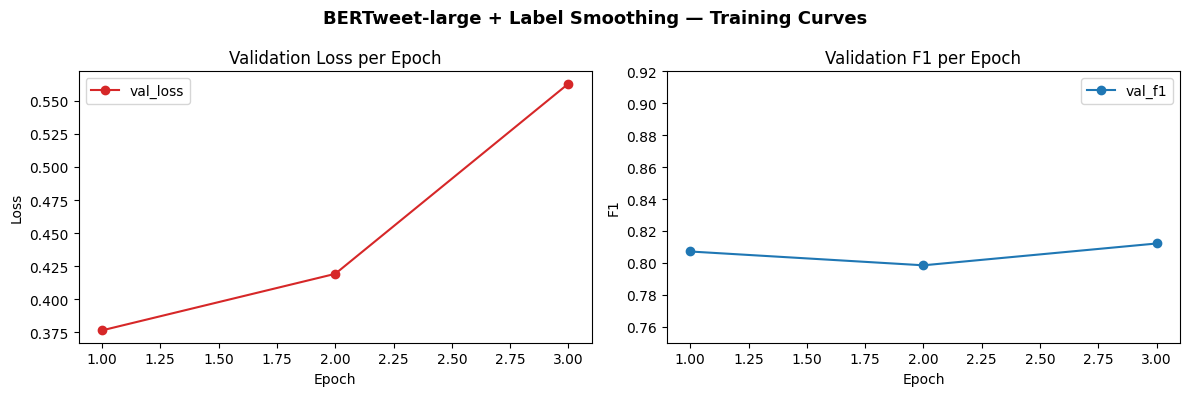

In [18]:
# =============================================================================
# TRAINING CURVES
# =============================================================================

epochs      = []
val_loss    = []
val_f1_hist = []

for entry in trainer.state.log_history:
    if 'eval_loss' in entry:
        epochs.append(entry['epoch'])
        val_loss.append(entry['eval_loss'])
        val_f1_hist.append(entry.get('eval_f1', None))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, val_loss, marker='o', label='val_loss', color='#d62728')
axes[0].set_title('Validation Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, val_f1_hist, marker='o', label='val_f1', color='#1f77b4')
axes[1].set_title('Validation F1 per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0.75, 0.92)
axes[1].legend()

plt.suptitle('BERTweet-large + Label Smoothing — Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/images/bert_bertweet_large/bertweet_large_training_curves.png',
            bbox_inches='tight')
plt.show()

In [19]:
# =============================================================================
# ERROR ANALYSIS
# =============================================================================

fp = val_df[(val_preds == 1) & (val_labels == 0)]['text_cleaned'].head(5)
fn = val_df[(val_preds == 0) & (val_labels == 1)]['text_cleaned'].head(5)

print("False Positives (predicted disaster, actually not):")
print(fp.to_string())
print("\nFalse Negatives (predicted not disaster, actually is):")
print(fn.to_string())

False Positives (predicted disaster, actually not):
6974     @ GreenLacey God ' s Love  &   # thank you my...
1206     ?  High Skies  -  Burning Buildings  ?    # n...
3017    6 Things Getting Caught in a Dust Storm  &  th...
4217      JAX issues Hazardous Weather Outlook  ( HWO )  
6766                         @ Ayshun_Tornado then do not

False Negatives (predicted not disaster, actually is):
6854    Photo :  lavender poetry cafe :  The Forgotten...
3651    Las Vegas in top 5 cities for red - light runn...
1303     bulletproof and black like a funeral ;  the w...
2491    Unexercised honda run - down neighborhood deso...
3134                           Emergency Flow   mp3  rar 


In [21]:
# =============================================================================
# FULL MODEL COMPARISON
# =============================================================================

print(f"\n{'='*60}")
print(f"  FULL MODEL COMPARISON")
print(f"{'='*60}")
print(f"  {'Model':<40} {'Val F1':<10} {'Kaggle F1'}")
print(f"  {'-'*60}")
print(f"  {'BiLSTM + GloVe 100d':<40} {'0.776':<10} {'0.809'}")
print(f"  {'BERT fine-tuning (bert-base-uncased)':<40} {'0.838':<10} {'0.839'}")
print(f"  {'BERT + LoRA (r=8)':<40} {'0.827':<10} {'0.833'}")
print(f"  {'BERTweet fine-tuning (bertweet-base)':<40} {'0.821':<10} {'0.839'}")
print(f"  {'BERTweet + LoRA (r=8)':<40} {'0.813':<10} {'0.846'}")
print(f"  {'BERTweet-large + label smoothing':<40} {f'{val_f1:.3f}':<10} {'(submit)'}")
print(f"{'='*60}")


  FULL MODEL COMPARISON
  Model                                    Val F1     Kaggle F1
  ------------------------------------------------------------
  BiLSTM + GloVe 100d                      0.776      0.809
  BERT fine-tuning (bert-base-uncased)     0.838      0.839
  BERT + LoRA (r=8)                        0.827      0.833
  BERTweet fine-tuning (bertweet-base)     0.821      0.839
  BERTweet + LoRA (r=8)                    0.813      0.846
  BERTweet-large + label smoothing         0.812      (submit)


In [23]:
# =============================================================================
# GENERATE SUBMISSION FILE
# =============================================================================

test_work    = df_test[['text_cleaned']].copy()
test_dataset = Dataset.from_pandas(test_work.reset_index(drop=True))
test_dataset = test_dataset.map(tokenize, batched=True)

model.eval()
all_test_preds = []

for i in range(0, len(test_dataset), BATCH_SIZE):
    batch          = test_dataset[i:i+BATCH_SIZE]
    input_ids      = [torch.tensor(x) for x in batch['input_ids']]
    attention_mask = [torch.tensor(x) for x in batch['attention_mask']]
    input_ids      = pad_sequence(input_ids, batch_first=True, padding_value=0).to(device)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_test_preds.extend(preds)
    print(f"  {min(i+BATCH_SIZE, len(test_dataset))}/{len(test_dataset)}")

submission = pd.DataFrame({
    'id'    : df_test['id'],
    'target': np.array(all_test_preds)
})
submission.to_csv('../data/submission_bertweet_large.csv', index=False)

print(f"\nSubmission saved to ../data/submission_bertweet_large.csv")
print(submission['target'].value_counts())

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

  8/3263
  16/3263
  24/3263
  32/3263
  40/3263
  48/3263
  56/3263
  64/3263
  72/3263
  80/3263
  88/3263
  96/3263
  104/3263
  112/3263
  120/3263
  128/3263
  136/3263
  144/3263
  152/3263
  160/3263
  168/3263
  176/3263
  184/3263
  192/3263
  200/3263
  208/3263
  216/3263
  224/3263
  232/3263
  240/3263
  248/3263
  256/3263
  264/3263
  272/3263
  280/3263
  288/3263
  296/3263
  304/3263
  312/3263
  320/3263
  328/3263
  336/3263
  344/3263
  352/3263
  360/3263
  368/3263
  376/3263
  384/3263
  392/3263
  400/3263
  408/3263
  416/3263
  424/3263
  432/3263
  440/3263
  448/3263
  456/3263
  464/3263
  472/3263
  480/3263
  488/3263
  496/3263
  504/3263
  512/3263
  520/3263
  528/3263
  536/3263
  544/3263
  552/3263
  560/3263
  568/3263
  576/3263
  584/3263
  592/3263
  600/3263
  608/3263
  616/3263
  624/3263
  632/3263
  640/3263
  648/3263
  656/3263
  664/3263
  672/3263
  680/3263
  688/3263
  696/3263
  704/3263
  712/3263
  720/3263
  728/3263
  736/3263
 

In [25]:
# =============================================================================
# KAGGLE SUBMISSION RESULTS
# =============================================================================
# Upload ../data/submission_bertweet_large.csv to:
# https://www.kaggle.com/competitions/nlp-getting-started/submissions

print(f"\n{'='*50}")
print(f"  KAGGLE SUBMISSION RESULTS")
print(f"{'='*50}")
print(f"  Model                   : vinai/bertweet-large")
print(f"  Epochs                  : {NUM_EPOCHS}")
print(f"  Learning rate           : {LEARNING_RATE}")
print(f"  Batch size              : {BATCH_SIZE}")
print(f"  Warmup ratio            : {WARMUP_RATIO}")
print(f"  Val F1                  : {eval_result['eval_f1']:.4f}")
print(f"  Kaggle Public F1        : 0.84400")
print(f"  Submission file         : ../data/submission_bertweet_large.csv")
print(f"  Competition link        : https://www.kaggle.com/competitions/nlp-getting-started/submissions")
print(f"{'='*50}")


  KAGGLE SUBMISSION RESULTS
  Model                   : vinai/bertweet-large
  Epochs                  : 3
  Learning rate           : 1e-05
  Batch size              : 8
  Warmup ratio            : 0.1
  Val F1                  : 0.8122
  Kaggle Public F1        : 0.84400
  Submission file         : ../data/submission_bertweet_large.csv
  Competition link        : https://www.kaggle.com/competitions/nlp-getting-started/submissions
